In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
import sys
import math
import datetime
from math import radians, cos, sin, asin, sqrt
from matplotlib.colors import LogNorm
from io import StringIO
from sklearn import linear_model
#import tensorflow as tf
from scipy import optimize
import math
#from scipy.optimize import curve_fit
plt.rcParams["font.sans-serif"]=["SimHei"] #用来正常显示中文标签
plt.rcParams["axes.unicode_minus"]=False #用来正常显示负号

In [2]:
from math import sin, asin, cos, radians, fabs, sqrt
EARTH_RADIUS=6371 
def hav(theta):
    s = sin(theta / 2)
    return s * s
def get_distance_hav(lat0, lng0, lat1, lng1):    #lat纬度
    lat0 = radians(lat0)
    lat1 = radians(lat1)
    lng0 = radians(lng0)
    lng1 = radians(lng1)
    dlng = fabs(lng0 - lng1)
    dlat = fabs(lat0 - lat1)
    h = hav(dlat) + cos(lat0) * cos(lat1) * hav(dlng)
    distance = 2 * EARTH_RADIUS * asin(sqrt(h))
    return distance

In [3]:
df=pd.read_csv('df.csv')   #筛选数据后的单车数据

In [25]:
sid=(np.load("5km起始区域id(bj).npy")).tolist()
sid1=pd.Series(sid)
eid=(np.load("5km终点区域id(bj).npy")).tolist()
eid1=pd.Series(eid)

In [26]:
df["sid"]=sid1   #起始id
df["eid"]=eid1   #终点id

In [27]:
s_eid=[]
for i in range(0,len(df)):
    c=[]
    a=df.iloc[i]["sid"]
    b=df.iloc[i]["eid"]
    c.append(a)
    c.append(b)
    s_eid.append(c)

In [28]:
for i in range(0,len(s_eid)):
    hr=s_eid[i]
    s_eid[i]=str(hr)

In [29]:
s_eid1=pd.Series(s_eid)
s_eid1

0          [607, 607]
1          [742, 742]
2          [380, 368]
3          [469, 469]
4          [646, 646]
              ...    
3094262    [721, 721]
3094263    [671, 671]
3094264    [314, 314]
3094265    [406, 406]
3094266      [90, 90]
Length: 3094267, dtype: object

In [30]:
df["s_eid"]=s_eid1

In [31]:
e_sid=[]
for i in range(0,len(df)):
    c=[]
    a=df.iloc[i]["sid"]
    b=df.iloc[i]["eid"]
    c.append(b)
    c.append(a)
    e_sid.append(c)

In [32]:
for i in range(0,len(e_sid)):
    hr=e_sid[i]
    e_sid[i]=str(hr)

In [33]:
e_sid1=pd.Series(e_sid)
e_sid1

0          [607, 607]
1          [742, 742]
2          [368, 380]
3          [469, 469]
4          [646, 646]
              ...    
3094262    [721, 721]
3094263    [671, 671]
3094264    [314, 314]
3094265    [406, 406]
3094266      [90, 90]
Length: 3094267, dtype: object

In [34]:
df["e_sid"]=e_sid1

In [35]:
df1_1=df[df["sid"]!=-1]

In [36]:
df1_2=df1_1[df1_1["eid"]!=-1]

In [37]:
df2 = pd.read_csv("5kmpopdata_bj.csv")      #包含区域人口数据
df2

,OBJECTID,Id,Shape_Length,Shape_Area,x,y,OBJECTID_1,Id_1,COUNT,AREA,SUM
0,1,1,19971.501500,2.499858e+07,115.869553,40.403523,1,1,3803,0.002641,7677.422747
1,2,2,7384.123866,2.400218e+06,117.263084,40.567047,2,2,370,0.000257,35.573828
2,3,3,20000.000000,2.500000e+07,116.737228,40.553127,3,3,3830,0.002660,323.334024
3,4,4,20000.000000,2.500000e+07,115.876099,40.447552,4,4,3706,0.002574,6223.365983
4,5,5,20000.000000,2.500000e+07,115.772301,39.743233,5,5,3774,0.002621,1633.166333
...,...,...,...,...,...,...,...,...,...,...,...
742,743,743,20000.000000,2.500000e+07,116.910858,40.136261,742,743,3798,0.002638,9207.310973
743,744,744,20000.000000,2.500000e+07,116.698807,40.690338,743,744,3833,0.002662,307.394893
744,745,745,20000.000000,2.500000e+07,116.198387,39.797012,744,745,3787,0.002630,39628.576820
745,746,746,20000.000000,2.500000e+07,116.420715,39.688919,745,746,3783,0.002627,25739.164470


In [38]:
id_=(df2["Id"]).tolist()
sum_=(df2["SUM"]).tolist()

In [39]:
pop_di=[]
for i in range(0,len(id_)):
    c=[]
    a=id_[i]
    b=sum_[i]
    c.append(a)
    c.append(b)
    pop_di.append(c)

In [40]:
pdict=dict(pop_di)    #区域：区域人口字典
pdict

{1: 7677.422747,
 2: 35.57382756,
 3: 323.3340239,
 4: 6223.365983,
 5: 1633.166333,
 6: 40697.31438,
 7: 912.3337046,
 8: 28963.869639999997,
 9: 5801.394988,
 10: 22759.72947,
 11: 18741.21806,
 12: 2353.068027,
 13: 7183.470748999999,
 14: 34728.01175,
 15: 4575.902155,
 16: 388.1672377,
 17: 457.1480831,
 18: 6806.062483,
 19: 3182.670913,
 20: 20152.14274,
 21: 4177.742216,
 22: 1091.0493179999999,
 23: 240.12132069999998,
 24: 2520.7042420000002,
 25: 54.92681015,
 26: 657.0794807,
 27: 21829.29945,
 28: 23123.67286,
 29: 74.16789809999999,
 30: 2418.434826,
 31: 17774.36162,
 32: 25.28170097,
 33: 89.20422828,
 34: 56867.7441,
 35: 1.8096637869999999,
 36: 5907.259275,
 37: 8756.522386,
 38: 63334.89076,
 39: 555.1347546000001,
 40: 26941.570819999997,
 41: 3793.7695700000004,
 42: 11.10550069,
 43: 35.93131034,
 44: 2587.570241,
 45: 18397.54288,
 46: 52082.558939999995,
 47: 455.56371629999995,
 48: 371.1696452,
 49: 1241.633959,
 50: 14624.644559999999,
 51: 937.4238562999999

In [41]:
df_io=df1_2[df1_2["sid"]!=df1_2["eid"]]   #不包含区域自流量的数据
df_io

,orderid,userid,bikeid,biketype,starttime,geohashed_start_loc,geohashed_end_loc,start_x,start_y,end_x,end_y,BJ,Travel_time(s),speed,sid,eid,s_eid,e_sid
2,2965085,549189,310572,1,2017-05-14 22:16:51,wx4fgur,wx4fu5n,116.542282,39.882431,116.551895,39.875565,1,625,1.792963,380,368,"[380, 368]","[368, 380]"
10,1116773,342055,137447,2,2017-05-14 22:16:54,wx4f9mt,wx4f9k4,116.429672,39.845352,116.425552,39.837112,1,391,2.510097,490,671,"[490, 671]","[671, 490]"
15,2956503,811790,309751,1,2017-05-14 22:16:58,wx4fcw2,wx4fct6,116.433792,39.893417,116.436539,39.887924,1,343,1.907329,689,490,"[689, 490]","[490, 689]"
20,3454200,81735,356681,1,2017-05-14 22:17:01,wx4g15v,wx4g1ej,116.418686,39.923630,116.440659,39.919510,1,611,3.157125,314,689,"[314, 689]","[689, 314]"
28,4059594,1021011,415138,1,2017-05-14 22:17:04,wx4dwmh,wx4dwk9,116.296463,39.842606,116.292343,39.839859,1,148,3.147767,572,244,"[572, 244]","[244, 572]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3094245,4894146,1007126,484849,1,2017-05-23 06:20:46,wx4f9hu,wx4f8vp,116.417313,39.841232,116.410446,39.842606,1,161,3.763135,671,619,"[671, 619]","[619, 671]"
3094250,1686749,634641,190868,2,2017-05-23 06:20:48,wx4dwmg,wx4dwmh,116.295090,39.846725,116.296463,39.842606,1,180,2.626521,244,572,"[244, 572]","[572, 244]"
3094252,3446200,1020584,355921,1,2017-05-23 06:20:49,wx4f94y,wx4f9jd,116.420059,39.830246,116.414566,39.845352,1,625,2.790334,671,619,"[671, 619]","[619, 671]"
3094257,1656522,942212,187966,2,2017-05-23 06:20:51,wx4u0tk,wx4u0g8,116.395340,40.107651,116.400833,40.098038,1,444,2.627375,410,406,"[410, 406]","[406, 410]"


In [42]:
s_id=(df1_2["sid"]).tolist()
e_id=(df1_2["eid"]).tolist()

In [43]:
s_eid=[]     #所有的区域id
s_eid.extend(s_id)
s_eid.extend(e_id)

In [44]:
seid1=pd.Series(s_eid)
un_id=seid1.value_counts()   #所有区域id   有的没有进或出流量
un_id1=(un_id.index).tolist()

In [45]:
outtr=[]     #某个区域的出入流量人口数目
intr=[]
popnu=[]
for i in range(0,len(un_id1)):
    z=un_id1[i]   #区域id
    dd=df_io[df_io["sid"]==z]  
    l1=len(dd)   #区域z的出流量
    outtr.append(l1)
    dd1=df_io[df_io["eid"]==z]
    l2=len(dd1)   #区域z的入流量
    intr.append(l2)
    popu=pdict[z]   #区域人口
    
    popnu.append(popu)

In [68]:
def f_1(x, A, B):
    return A * x + B
x0 =outtr
y0 =intr
A1, B1 = optimize.curve_fit(f_1, x0, y0)[0]
x1 = np.arange(0,34442, 0.01)#30和75要对应x0的两个端点，0.01为步长
y1 = A1 * x1 + B1

In [69]:
print(A1)
print(B1)

0.9822131038781947
46.443862496734944


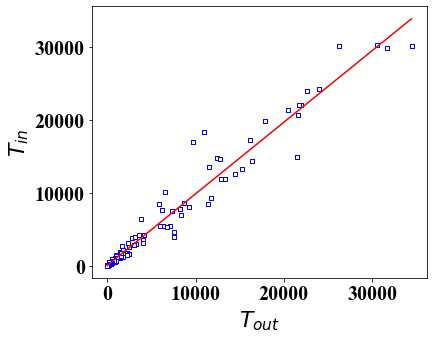

In [70]:
fig= plt.figure(figsize=(6,5))        #一个区域的出和进流量
ax = fig.add_subplot(1,1,1) 
plt.scatter(outtr,intr,marker = 's',color="w",linewidths=1,s=20,edgecolors='blue')
plt.plot(x1, y1, "red")  #y=0.9920583455398205x+1.4924510808168334
#plt.scatter(popnu,intr,marker = 's',color="w",linewidths=1,s=20,edgecolors='red',label="Tin",alpha=0.6)
#plt.plot( eavd,eloc_num, marker='.',color="red",label="in_Tij",alpha=0.1)
#plt.legend(loc="best",prop={'size':20,'family':'Times New Roman'})
#ax.set_yscale("log")
#ax.set_xscale("log")
plt.yticks(fontproperties = 'Times New Roman')
plt.xticks(fontproperties = 'Times New Roman') 
ax.set_ylabel("$T_{in}$",size=22,family='Times New Roman')  
ax.set_xlabel("$T_{out}$",size=22,family='Times New Roman')
plt.tick_params(labelsize=20)